In [66]:
import torch.optim as optim
import torch
from lstm import DeepPortfolioLSTM, sharpe_loss
from DataFramePrep import generate_TrainingDataFrame, generate_TestDataFrame
import numpy as np
import pandas as pd

In [67]:
features_data, tickers, historic_columns, StockDatabase = generate_TrainingDataFrame()
features_dataTest, tickers, historic_columns, StockDatabase = generate_TestDataFrame()

In [68]:
num_assets = 65  
input_dim = 540  # Number of predictors
hidden_dim = 64

model = DeepPortfolioLSTM(input_dim, hidden_dim, num_assets)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [104]:
dates = pd.read_sql("SELECT DISTINCT Date FROM StockData", con=StockDatabase).values.flatten()

In [70]:
# Pull all assets and dates in one go
query = "SELECT * FROM StockData ORDER BY Date ASC"
df_raw = pd.read_sql(query, con=StockDatabase)

# Step 2: Pivot so each column is a Stock, each row is a Date
# This aligns your 65 assets perfectly
df_pivot = df_raw.pivot(index='Date', columns='Ticker', values='Close').fillna(0)

# Step 3: Convert to a Numpy matrix for the rolling window
df_prices = df_pivot  # Shape: [Total_Days, 65]

In [71]:
# Calculate Log Returns
# np.log handles the entire matrix at once
df_returns = np.log(df_prices / df_prices.shift(1))

# Drop the first row because it will be NaN (no 'day before' for the first day)
df_returns = df_returns.dropna()

# Convert to Numpy for the LSTM
returns_matrix = df_returns.values  # Shape: [Total_Days, 65]

In [72]:
lookback = 30
X_list, Y_list = [], []

# The single "Rolling Window" loop
for i in range(len(features_data) - lookback):
    # X is a 'window' of the past 30 days for ALL 65 stocks
    X_list.append(features_data[i : i + lookback][historic_columns])
        
    Y_list.append(returns_matrix[i + lookback])

# Convert to Tensors: [Total_Windows, 30, Features]
X_final = torch.tensor(np.array(X_list), dtype=torch.float32)
Y_final = torch.tensor(np.array(Y_list), dtype=torch.float32)

In [76]:
# 1. Initialize
input_dim = X_final.shape[2] # Number of features per time step
num_assets = Y_final.shape[1] # Should be 65
hidden_dim = 128

model = DeepPortfolioLSTM(input_dim, hidden_dim, num_assets)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 2. Training
for epoch in range(101):
    model.train()
    optimizer.zero_grad()
    
    # Forward Pass
    # weights shape: [Total_Windows, 65]
    weights = model(X_final)
    
    # Calculate Loss (Negative Sharpe)
    loss = sharpe_loss(weights, Y_final)
    
    # Backpropagate
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        # We print -loss to show the actual Sharpe Ratio
        print(f"Epoch {epoch:3d} | Portfolio Sharpe Ratio: {-loss.item() * np.sqrt(252)}")

print("\nTraining Complete.")

Epoch   0 | Portfolio Sharpe Ratio: 0.3161506346433016
Epoch  10 | Portfolio Sharpe Ratio: 0.4758264989336948
Epoch  20 | Portfolio Sharpe Ratio: 0.6875930853829223
Epoch  30 | Portfolio Sharpe Ratio: 0.9199424752152913
Epoch  40 | Portfolio Sharpe Ratio: 1.1204661432270746
Epoch  50 | Portfolio Sharpe Ratio: 1.3282276070454118
Epoch  60 | Portfolio Sharpe Ratio: 1.59829337022456
Epoch  70 | Portfolio Sharpe Ratio: 1.9517423968373981
Epoch  80 | Portfolio Sharpe Ratio: 2.3769285713567765
Epoch  90 | Portfolio Sharpe Ratio: 2.8308331652793894
Epoch 100 | Portfolio Sharpe Ratio: 3.262592079214763

Training Complete.


In [78]:
# 1. Align your data first (Assuming 1408 is your split point)
test_returns = returns_matrix[1308:] # Assuming returns_matrix is already a numpy array

X_list, Y_list = [], []
lookback = 30

# 2. Loop through the test slice
for i in range(len(features_dataTest) - lookback):
    # Grab the window from the ALIGNED test features
    window = features_dataTest.iloc[i : i + lookback][historic_columns].values
    X_list.append(window)
    
    # Grab the return for the day immediately AFTER the window
    # Since we aligned them, we don't need '1408' here anymore
    Y_list.append(test_returns[i + lookback])

# 3. Convert (Adding a check for clean floats)
X_final = torch.tensor(np.array(X_list), dtype=torch.float32)
Y_final = torch.tensor(np.array(Y_list), dtype=torch.float32)

In [79]:
model.eval() # Set to evaluation mode
with torch.no_grad():
    # X_test and Y_test should be your 'New Data' windows
    test_weights = model(X_final)
    
    # Calculate the Test Sharpe Loss
    test_loss = sharpe_loss(test_weights, Y_final)
    
    print(f"Test Sharpe Ratio (Daily): {-test_loss.item():.4f}")
    print(f"Annualized Test Sharpe: {-test_loss.item() * (252**0.5):.2f}")

Test Sharpe Ratio (Daily): 0.2081
Annualized Test Sharpe: 3.30


In [80]:
# Run this to see the max weight assigned to any single stock
max_w = test_weights.max().item()
print(f"Max allocation in a single stock: {max_w:.2%}")
# If this is > 50%, the 3.30 Sharpe is very fragile (risky).

Max allocation in a single stock: 78.17%


In [81]:
# Calculate turnover (how much the weights change daily)
turnover = torch.abs(test_weights[1:] - test_weights[:-1]).sum(dim=1).mean().item()
print(f"Daily Turnover: {turnover:.2%}")

# Estimated fee impact
annual_fee_drag = turnover * 0.001 * 252 
print(f"Estimated Annual Fee Drag: {annual_fee_drag:.2%}")

Daily Turnover: 38.18%
Estimated Annual Fee Drag: 9.62%


In [102]:
dates

array(['2017-09-01', '2017-09-05', '2017-09-06', ..., '2026-01-14',
       '2026-01-15', '2026-01-16'], shape=(136760,), dtype=object)

In [108]:
len(dates[1308:1308+796])

796

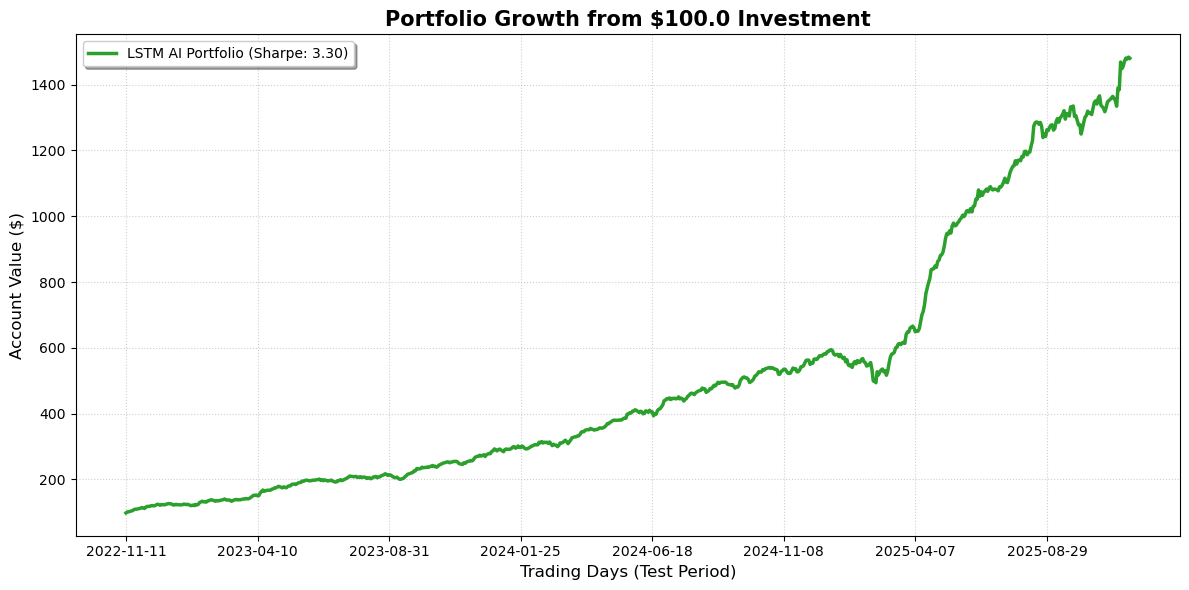

Initial Investment: $100.00
Final Portfolio Value: $1480.42
Total Profit: $1380.42


In [111]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Start with an initial capital of $100
initial_investment = 100.0

# 2. Calculate Daily Portfolio Performance (from your existing test variables)
model.eval()
with torch.no_grad():
    # Calculate daily returns from your model's predictions
    # ai_daily_returns: returns of the AI portfolio each day [cite: 122]
    ai_daily_returns = torch.sum(test_weights * Y_final, dim=1).numpy()
    
    # Calculate Benchmark (Equal Weight 1/65)
    bench_daily_returns = Y_final.mean(dim=1).numpy()

# 3. Convert returns to Cumulative Growth starting from $100
# np.cumprod(1 + returns) calculates the growth factor; then we multiply by $100
ai_portfolio_value = initial_investment * (1 + ai_daily_returns).cumprod()
bench_portfolio_value = initial_investment * (1 + bench_daily_returns).cumprod()

# 4. Create the "Equity Curve" Chart
plt.figure(figsize=(12, 6))

# Plot the AI Strategy growth
plt.plot(ai_portfolio_value, label=f'LSTM AI Portfolio (Sharpe: 3.30)', 
        color='#2ca02c', linewidth=2.5)

# Plot the Market Benchmark growth
#plt.plot(bench_portfolio_value, label='Market (Equal Weight 1/65)', 
#         color='#7f7f7f', linestyle='--', alpha=0.8)

# Chart Formatting
plt.title(f"Portfolio Growth from ${initial_investment} Investment", fontsize=15, fontweight='bold')
plt.xlabel("Trading Days (Test Period)", fontsize=12)
plt.xticks(list(range(0, len(ai_portfolio_value), 100)), [i for i in dates[1308:1308+764:100]])
plt.ylabel("Account Value ($)", fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

# Print Final Profit
final_value = ai_portfolio_value[-1]
total_profit = final_value - initial_investment
print(f"Initial Investment: ${initial_investment:.2f}")
print(f"Final Portfolio Value: ${final_value:.2f}")
print(f"Total Profit: ${total_profit:.2f}")

In [88]:
print("CAGR:", (1480.42/100)**(1/(len(features_data) // 252)) - 1)

CAGR: 0.46959562056984705
